In [1]:
class AgentState:
    pass

In [2]:
def run_initialize_session(state: AgentState) -> AgentState:
    """Sets up the initial environment and state variables."""
    pass

def run_check_system_readiness(state: AgentState) -> str:
    """Validates hardware/API access before starting."""
    pass

def run_deliver_question(state: AgentState) -> AgentState:
    """Triggers the AI to ask the current question."""
    pass

def run_capture_and_process_response(state: AgentState) -> AgentState:
    """Handles audio recording and speech-to-text conversion."""
    pass

def run_decide_next_step(state: AgentState) -> str:
    """Determines if more questions remain or if the session is complete."""
    pass

In [9]:
from langgraph.graph import END, START, StateGraph

workflow = StateGraph(AgentState)

workflow.add_node("initialize_session", run_initialize_session)
workflow.add_node("deliver_question", run_deliver_question)
workflow.add_node("capture_and_process_response", run_capture_and_process_response)

workflow.add_edge(START, "initialize_session")
workflow.add_conditional_edges(
    "initialize_session",
    run_check_system_readiness,
    {
        "success": "deliver_question",
        "failure": END
    }
)

workflow.add_edge("deliver_question", "capture_and_process_response")
workflow.add_conditional_edges(
    "capture_and_process_response",
    run_decide_next_step,
    {
        "yes": "deliver_question",
        "no": END
    }
)

agent = workflow.compile()

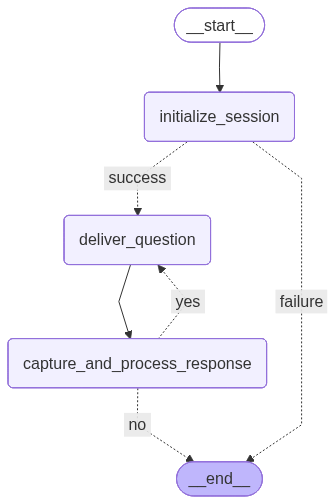

In [10]:
from IPython.display import Image, display

display(Image(agent.get_graph().draw_mermaid_png()))